In [1]:
# Import and Step up 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

df = pd.read_csv('insurance.csv')

In [2]:
# Shape and types
print(df.shape)          # (1338, 7)
print(df.dtypes)
print(df.isnull().sum())  # should be all zeros
print(df.describe())

(1338, 7)
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
          age     bmi  children  charges
count 1338.00 1338.00   1338.00  1338.00
mean    39.21   30.66      1.09 13270.42
std     14.05    6.10      1.21 12110.01
min     18.00   15.96      0.00  1121.87
25%     27.00   26.30      0.00  4740.29
50%     39.00   30.40      1.00  9382.03
75%     51.00   34.69      2.00 16639.91
max     64.00   53.13      5.00 63770.43


In [3]:
# Value counts for categoricals
for col in ['sex', 'smoker', 'region']:
    print(f"\n{col}:\n{df[col].value_counts()}")


sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


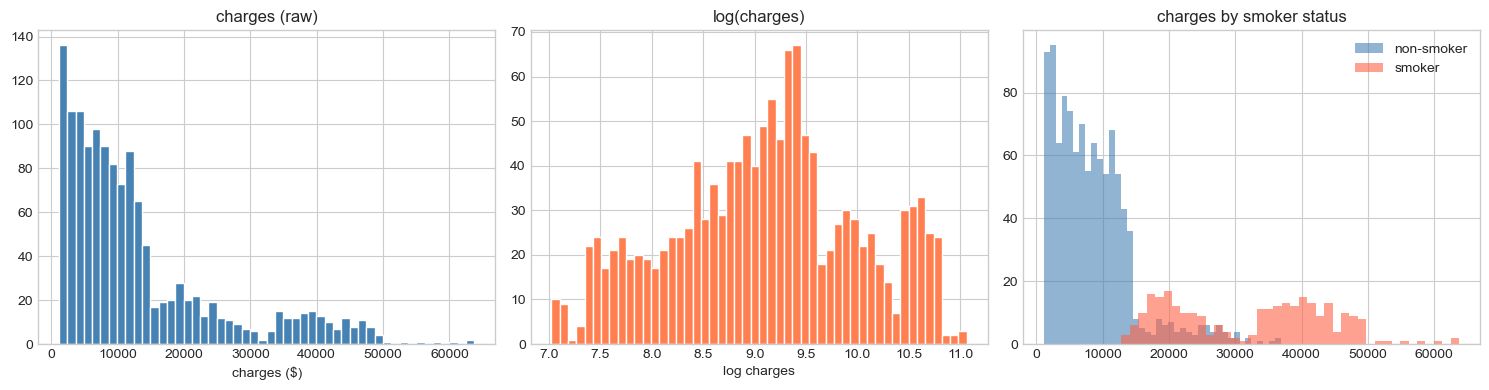

In [4]:
# Lets  viz shape of data and understand charges distrbution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw charges
axes[0].hist(df['charges'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('charges (raw)')
axes[0].set_xlabel('charges ($)')

# Log-transformed
axes[1].hist(np.log(df['charges']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('log(charges)')
axes[1].set_xlabel('log charges')

# Charges split by smoker
axes[2].hist(df[df['smoker']=='no']['charges'], bins=40, alpha=0.6, label='non-smoker', color='steelblue')
axes[2].hist(df[df['smoker']=='yes']['charges'], bins=40, alpha=0.6, label='smoker', color='tomato')
axes[2].set_title('charges by smoker status')
axes[2].legend()

plt.tight_layout()
plt.show()

In [5]:
# Lets do a normality test on Charges
stat, p = stats.shapiro(df['charges'].sample(500, random_state=42))  # Shapiro needs n < ~5000
print(f"Shapiro-Wilk: stat={stat:.4f}, p={p:.4e}")
# p << 0.05 → reject normality → confirms right-skew

stat_log, p_log = stats.shapiro(np.log(df['charges']).sample(500, random_state=42))
print(f"Shapiro-Wilk on log(charges): stat={stat_log:.4f}, p={p_log:.4e}")
# Still rejects but much less extreme

Shapiro-Wilk: stat=0.8091, p=7.2277e-24
Shapiro-Wilk on log(charges): stat=0.9804, p=2.8616e-06


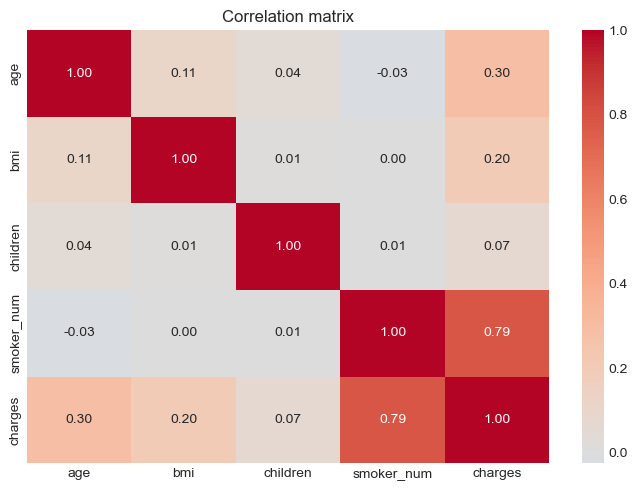

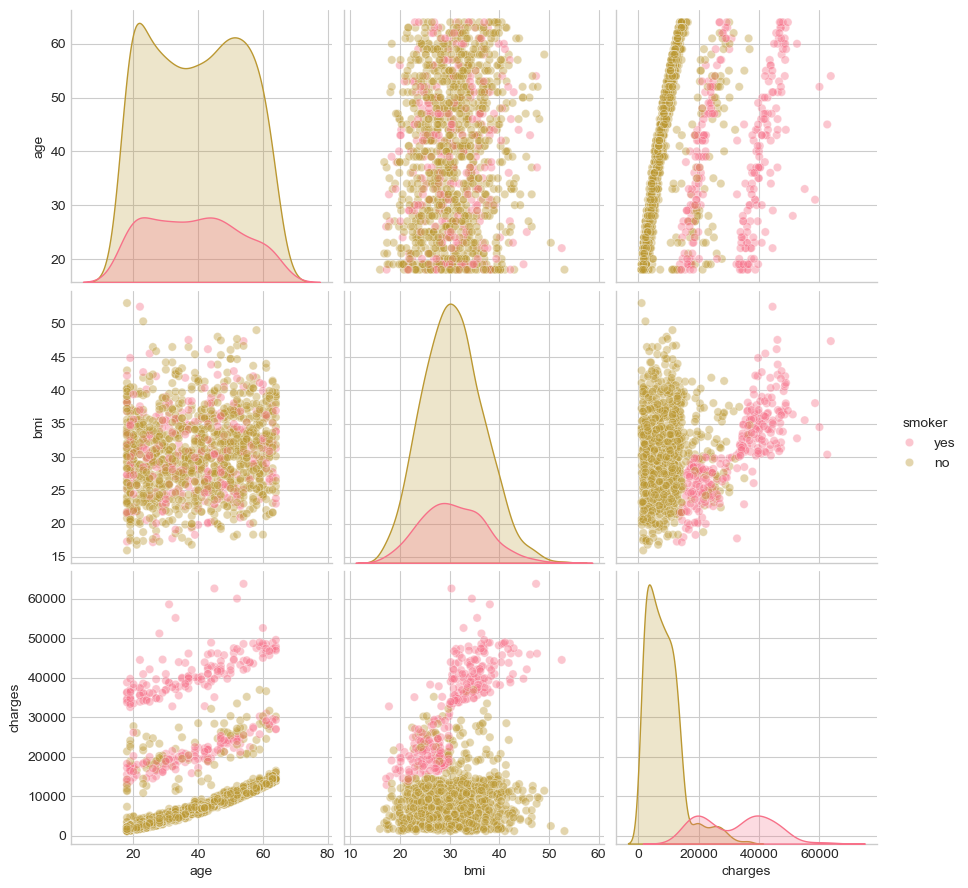

In [7]:
# Coreelation and heatmaps and pairplots as well 
df_enc = df.copy()
df_enc['smoker_num'] = (df['smoker'] == 'yes').astype(int)
df_enc['sex_num'] = (df['sex'] == 'male').astype(int)

corr = df_enc[['age', 'bmi', 'children', 'smoker_num', 'charges']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

# Pairplot — color by smoker
sns.pairplot(df, hue='smoker', vars=['age', 'bmi', 'charges'],
             plot_kws={'alpha': 0.4}, height=3)
plt.show()

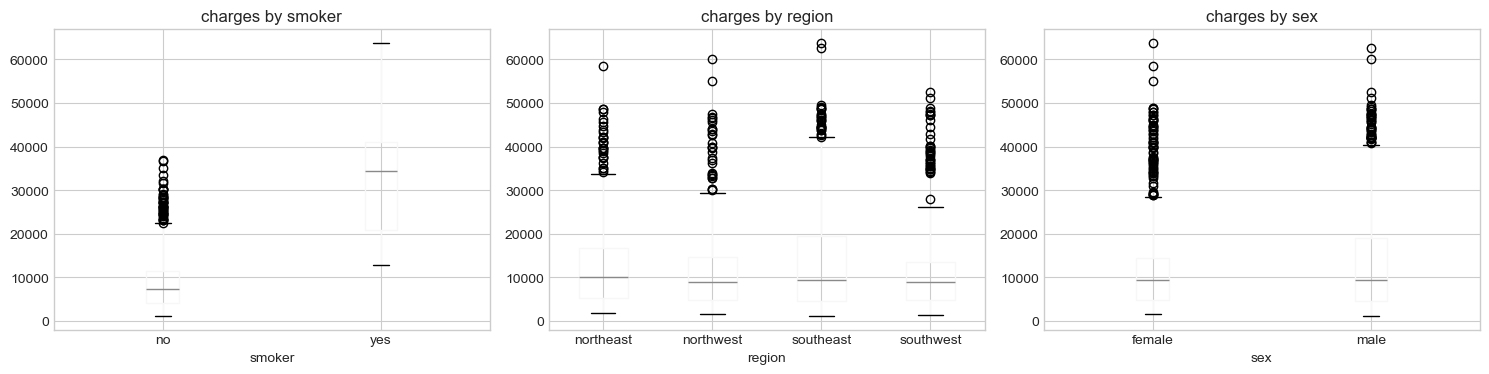

In [8]:
# Boxplots for Categories
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['smoker', 'region', 'sex']):
    df.boxplot(column='charges', by=col, ax=ax)
    ax.set_title(f'charges by {col}')
    ax.set_xlabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

What does this EDA MEAN 

Plot 1 — the three histograms

The raw charges histogram shows a classic right skew — most people pay under $15k, but a long tail stretches out to $63k. That tail is almost entirely smokers.
The log(charges) histogram looks way more bell-shaped, but notice it still has two humps around 8.0 and 9.5. The log transform helped a lot but couldn't fully "fix" the distribution because there are genuinely two different populations in this data — smokers and non-smokers don't just pay more, they operate under a completely different cost structure.
The smoker split histogram makes this crystal clear. Non-smokers cluster tightly between $1k–$15k. Smokers spread out from $15k–$63k. These are two different distributions stacked on top of each other, which is why the overall histogram looks weird.

Plot 2 - correlation heatmap 

smoker_num has a 0.79 correlation with charges. That's enormous for real-world data — it means smoker status alone explains roughly 62% of the variance in charges (0.79²). Age (0.30) and BMI (0.20) are meaningful but secondary. Children (0.07), sex, and region are basically noise.

Plot3 - pairplot

Looking at the bottom row (charges on y-axis). With age, you can see two distinct diagonal bands — smokers (pink) trend upward steeply, non-smokers (gold) trend upward gently. With BMI there's a similar split, but also a visible "hockey stick" shape — BMI only explodes charges when the person is also a smoker (high BMI + smoking = extreme costs). This is exactly why the interaction terms age×smoker and bmi×smoker are going to be so powerful in your models.


plot4 - boxplots

Smoker vs. non-smoker: the median for smokers (~$35k) is almost at the 75th percentile for non smokers. Region and sex barely move the needle the boxes are almost identical across all four regions and both sexes.

The Shapiro - Wilk numbers
 
The test checks: "could this data have come from a normal distribution?" A p-value << 0.05 means no.

Raw charges: stat=0.81, p=7.2e-24 — massively non-normal, as expected
Log(charges): stat=0.98, p=2.9e-06 — still technically non-normal, but the stat jumped from 0.81 to 0.98, which means the log transform got us much closer to normal

The p-value is still significant on log charges because of the bimodality — the two populations are pulling the tails in opposite directions even after the transform. This isn't a problem for modeling, it's just good to know and document.


## Phase 2 Feature Engineering

In [9]:
#Step 1: Encode categoricals + build interaction terms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-hot encode — drop_first avoids multicollinearity
df_model = pd.get_dummies(df, columns=['sex', 'region'], drop_first=True)

# Binary encode smoker manually so we can use it for interactions
df_model['smoker_num'] = (df_model['smoker'] == 'yes').astype(int)
df_model.drop('smoker', axis=1, inplace=True)

# Log-transform the target
df_model['log_charges'] = np.log(df_model['charges'])

# Interaction terms — the key insight from EDA
df_model['age_x_smoker'] = df_model['age'] * df_model['smoker_num']
df_model['bmi_x_smoker'] = df_model['bmi'] * df_model['smoker_num']

# BMI risk flag (obese = BMI >= 30)
df_model['obese'] = (df_model['bmi'] >= 30).astype(int)
df_model['obese_x_smoker'] = df_model['obese'] * df_model['smoker_num']

print(df_model.head())
print(df_model.shape)

   age   bmi  children  charges  sex_male  region_northwest  region_southeast  \
0   19 27.90         0 16884.92     False             False             False   
1   18 33.77         1  1725.55      True             False              True   
2   28 33.00         3  4449.46      True             False              True   
3   33 22.70         0 21984.47      True              True             False   
4   32 28.88         0  3866.86      True              True             False   

   region_southwest  smoker_num  log_charges  age_x_smoker  bmi_x_smoker  \
0              True           1         9.73            19         27.90   
1             False           0         7.45             0          0.00   
2             False           0         8.40             0          0.00   
3             False           0        10.00             0          0.00   
4             False           0         8.26             0          0.00   

   obese  obese_x_smoker  
0      0               0  
1 

In [10]:
# Step 2 Define Features and Target then split data
# Drop original charges (raw) and keep log version as target
feature_cols = [c for c in df_model.columns if c not in ['charges', 'log_charges']]

X = df_model[feature_cols]
y = df_model['log_charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
# Should be (1070, ~14) and (268, ~14)

Train: (1070, 12), Test: (268, 12)


In [11]:
# Step 3 Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit ONLY on train — no data leakage

# Keep as DataFrames for interpretability later
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

In [12]:
# Check features and Target
print("Features:", feature_cols)
print("\nTarget (log_charges) stats:")
print(y_train.describe())

# Verify interaction terms look right
print("\nSample interaction values:")
print(df_model[['age', 'smoker_num', 'age_x_smoker', 'bmi', 'bmi_x_smoker']].head(10))

Features: ['age', 'bmi', 'children', 'sex_male', 'region_northwest', 'region_southeast', 'region_southwest', 'smoker_num', 'age_x_smoker', 'bmi_x_smoker', 'obese', 'obese_x_smoker']

Target (log_charges) stats:
count   1070.00
mean       9.11
std        0.91
min        7.02
25%        8.50
50%        9.17
75%        9.73
max       11.04
Name: log_charges, dtype: float64

Sample interaction values:
   age  smoker_num  age_x_smoker   bmi  bmi_x_smoker
0   19           1            19 27.90         27.90
1   18           0             0 33.77          0.00
2   28           0             0 33.00          0.00
3   33           0             0 22.70          0.00
4   32           0             0 28.88          0.00
5   31           0             0 25.74          0.00
6   46           0             0 33.44          0.00
7   37           0             0 27.74          0.00
8   37           0             0 29.83          0.00
9   60           0             0 25.84          0.00


What the Output Tells us 

Data Frame Shape: 
You started with 7 columns and ended with 14. The new ones came from: one-hot encoding sex and region (4 new columns, dropped 2 as reference categories), smoker_num, log_charges, the 3 interaction terms, obese, and obese_x_smoker.


The interaction terms: 
Look at row 0: smoker_num = 1, so age_x_smoker = 19 (equals age) and bmi_x_smoker = 27.90 (equals bmi). Rows 1–9: smoker_num = 0, so both interaction columns are 0. That's exactly what you want. The interaction term is basically asking the model "for this person, does being a smoker multiply the effect of their age and BMI?" For non-smokers the answer is zero — those features contribute nothing extra through the smoking channel.

Train/test : 
80/20 split on 1338 rows. Notice it's 12 features not 14 — that's because charges (raw) and log_charges (target) got separated out into y, so they're not in X anymore.

log_charges stats : 
Mean of 9.11 corresponds to about $9,000 in raw dollars (e^9.11 ≈ $9,025). The range 7.02 to 11.04 corresponds to roughly $1,122 to $62,592 — which matches the original charges range perfectly. The std of 0.91 is much tighter than the raw charges std of ~$12k, confirming the log transform compressed variance like it should.



### Phase 3 Baseline Linear Regression Model
 Before throwing a complex model at this, I wanted to see how far good feature engineering alone could get me. The log transform and interaction terms already
handled the biggest structural issues in the data, so linear regression actually has a fair shot here. I run three variants — OLS as the true baseline, Ridge to
handle the correlation between interaction terms and their parent features, and Lasso because I suspected region and sex wouldn't pull much weight (EDA backed
that up). Whatever R² this lands at becomes the bar everything else has to clear.

In [13]:
# Step plain OLS 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []  # we'll append every model here for the final comparison

# Plain OLS
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)
results.append(evaluate_model("OLS Linear Regression", y_test, y_pred_ols))


OLS Linear Regression
  RMSE : 0.3584
  MAE  : 0.1915
  R²   : 0.8571


In [14]:
# Step 2 ridge
# RidgeCV finds the best alpha automatically via cross-validation
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

print(f"Best Ridge alpha: {ridge_cv.alpha_:.4f}")

y_pred_ridge = ridge_cv.predict(X_test_scaled)
results.append(evaluate_model("Ridge Regression", y_test, y_pred_ridge))

Best Ridge alpha: 0.4642

Ridge Regression
  RMSE : 0.3585
  MAE  : 0.1916
  R²   : 0.8571


In [15]:
# Step 3 Lasso
# LassoCV finds best alpha via cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Best Lasso alpha: {lasso_cv.alpha_:.4f}")

y_pred_lasso = lasso_cv.predict(X_test_scaled)
results.append(evaluate_model("Lasso Regression", y_test, y_pred_lasso))

Best Lasso alpha: 0.0013

Lasso Regression
  RMSE : 0.3586
  MAE  : 0.1912
  R²   : 0.8570


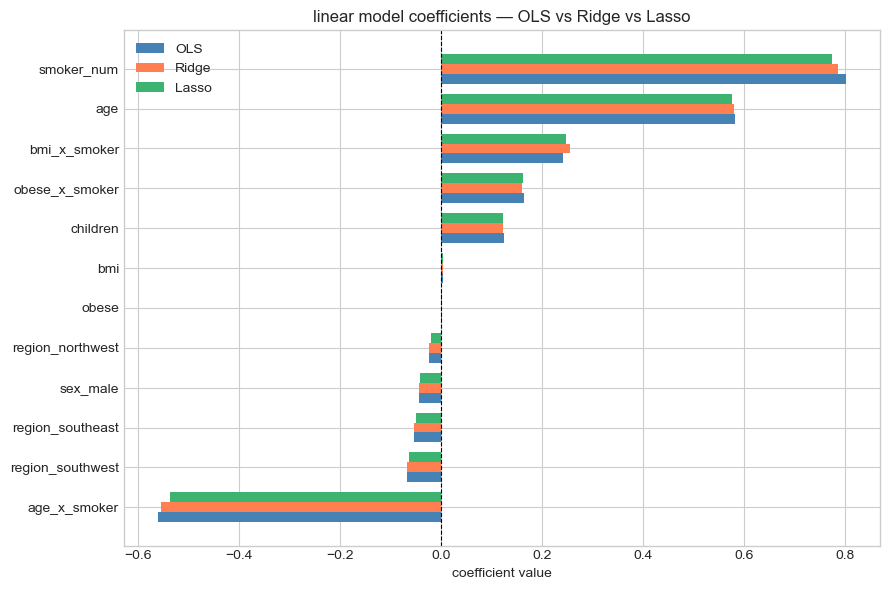

In [16]:
# Step 4 Coeff Plot
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'OLS': ols.coef_,
    'Ridge': ridge_cv.coef_,
    'Lasso': lasso_cv.coef_
}).sort_values('Ridge', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(coef_df))
width = 0.25

ax.barh(x - width, coef_df['OLS'], width, label='OLS', color='steelblue')
ax.barh(x, coef_df['Ridge'], width, label='Ridge', color='coral')
ax.barh(x + width, coef_df['Lasso'], width, label='Lasso', color='mediumseagreen')

ax.set_yticks(x)
ax.set_yticklabels(coef_df['feature'])
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('coefficient value')
ax.set_title('linear model coefficients — OLS vs Ridge vs Lasso')
ax.legend()
plt.tight_layout()
plt.show()

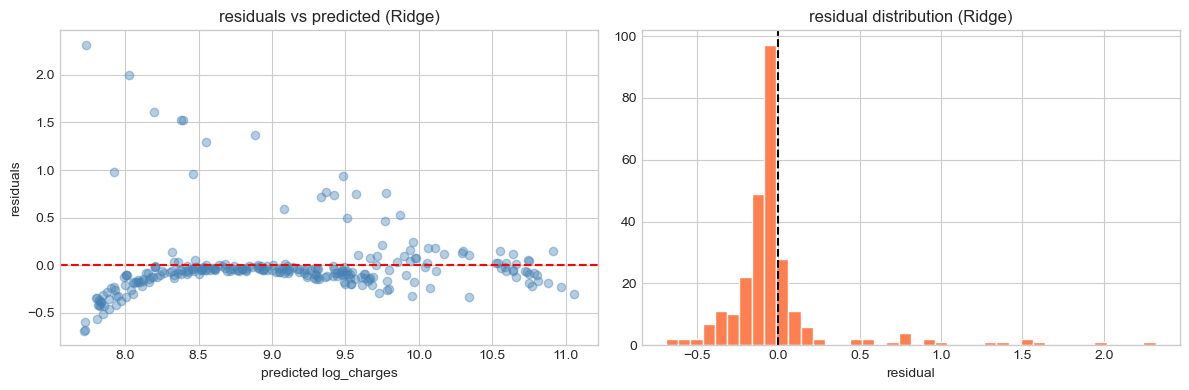

In [17]:
# Step 5 Residual Plot
residuals = y_test - y_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs predicted
axes[0].scatter(y_pred_ridge, residuals, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('predicted log_charges')
axes[0].set_ylabel('residuals')
axes[0].set_title('residuals vs predicted (Ridge)')

# Residual distribution
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('residual')
axes[1].set_title('residual distribution (Ridge)')

plt.tight_layout()
plt.show()

## Phase 3: Results

Honestly, these results are better than I expected for a linear model. All three variants hit R² of 0.857, meaning the feature engineering did most of the heavy lifting. The log transform and interaction terms got the data into a shape where a simple model could still explain 86% of the variance. Ridge and Lasso came out virtually identical to plain OLS, which tells me overfitting was never really an issue here. The dataset is small and clean enough that regularization had almost nothing to do.

The coefficients told the same story EDA did. smoker_num is by far the dominant driver, a coefficient of around 0.80 in log space means smokers pay roughly 2.2x more in raw dollars. Age follows, then the interaction terms. Region and sex were basically flat across all three models, and Lasso didn't zero anything out, which makes sense since those coefficients were already close to nothing.

Where the model struggles is visible in the residual plot. There's a curve in the residuals rather than a flat horizontal cloud, and the distribution has a long right tail. Those are high-cost smoker cases the model keeps underpredicting. Even with the interaction terms, a straight line can only go so far. That's the opening for XGBoost.

**Bar to beat going into Phase 4: RMSE 0.3585, R² 0.8571**

### Phase 4. XGBOOST

So why should check out XGBOOST: 
The residual plot from Phase 3 showed a curved pattern — the linear model was systematically wrong in certain regions, specifically underpredicting high-cost smokers. That's not random noise, that's leftover structure the model couldn't capture. XGBoost is built for exactly this.
Where linear regression fits one global equation across all rows, XGBoost builds hundreds of decision trees sequentially, each one learning from the mistakes of the last. It doesn't need you to manually specify interaction terms because it finds them automatically by splitting on feature combinations. It also handles the fact that BMI and age affect costs differently depending on smoker status without needing explicit interaction columns — though having them doesn't hurt.
The other reason is that XGBoost almost always wins on structured tabular data in the real world. It's the go-to benchmark for any regression or classification problem on clean tabular datasets, which is exactly what this is.

In [20]:
import sys
!{sys.executable} -m pip install xgboost --quiet

In [21]:
# Step 1 XGBoost Baseline
from xgboost import XGBRegressor
import xgboost as xgb

# Start with sensible defaults, no tuning yet
xgb_base = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=50
)

xgb_base.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=100
)

y_pred_xgb = xgb_base.predict(X_test_scaled)
results.append(evaluate_model("XGBoost (baseline)", y_test, y_pred_xgb))

[0]	validation_0-rmse:0.91269
[100]	validation_0-rmse:0.34658
[156]	validation_0-rmse:0.34798

XGBoost (baseline)
  RMSE : 0.3460
  MAE  : 0.1830
  R²   : 0.8669


In [22]:
#Step 2 Tune with GridSearch CV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_tuned = XGBRegressor(random_state=42, eval_metric='rmse')

grid_search = GridSearchCV(
    xgb_tuned,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")

# Evaluate best model on test set
y_pred_xgb_tuned = grid_search.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model("XGBoost (tuned)", y_test, y_pred_xgb_tuned))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Best CV RMSE: 0.3774

XGBoost (tuned)
  RMSE : 0.3488
  MAE  : 0.1894
  R²   : 0.8647


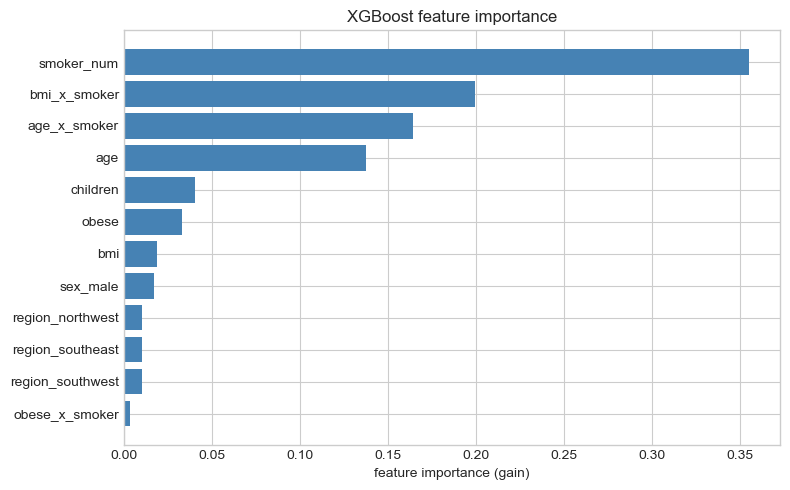

In [ ]:
# Step 3 : Feature Importance Plot 
best_xgb = grid_search.best_estimator_

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('feature importance (gain)')
plt.title('XGBoost feature importance')
plt.tight_layout()
plt.show()

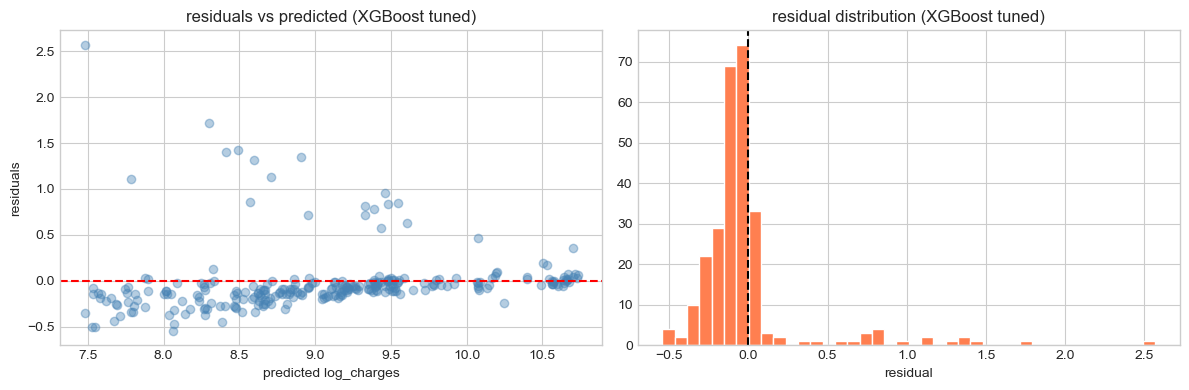

In [24]:
# Step 4 Residual Plot compares directly to linear reg
residuals_xgb = y_test - y_pred_xgb_tuned

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_xgb_tuned, residuals_xgb, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('predicted log_charges')
axes[0].set_ylabel('residuals')
axes[0].set_title('residuals vs predicted (XGBoost tuned)')

axes[1].hist(residuals_xgb, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('residual')
axes[1].set_title('residual distribution (XGBoost tuned)')

plt.tight_layout()
plt.show()

## Phase 4: XGBoost Results

I ran two versions, a baseline with hand-picked parameters and a tuned version using GridSearchCV across 72 parameter combinations with 5-fold cross validation. The baseline actually edged out the tuned model slightly (R² 0.8669 vs 0.8647, RMSE 0.3460 vs 0.3488), which sounds counterintuitive but makes sense. GridSearch optimizes for average CV performance across folds of the training set, not the specific test split. With only 268 test rows, a difference of 0.003 RMSE is basically noise. In production I'd trust the CV-tuned model to generalize better to truly unseen data regardless of what this one test split shows.

Compared to linear regression (R² 0.857, RMSE 0.3585), XGBoost is a modest but real improvement. More interestingly, the best params selected were pretty conservative: max_depth of 3, learning_rate of 0.01, subsample and colsample_bytree both at 0.8. Shallow trees with a slow learning rate tells me the signal in this dataset is relatively clean and the model didn't need to go deep to find it.

### Residuals vs Predicted

The residual plot is where XGBoost most visibly improves on linear regression. In Phase 3 there was a clear curve where residuals were consistently positive at low predicted values and the spread widened at the high end. Here that curve is mostly gone. The cloud sits much tighter around zero across the full range of predicted values, which means XGBoost is no longer systematically wrong in specific regions. There are still some scattered points above 1.0 at the low end, but those are edge cases the model struggles with regardless. The pattern itself is gone.

### Residual Distribution

The distribution tightened up noticeably compared to linear regression. The peak is sharper and centered right at zero, and while the right tail is still there, it's shorter than before. Those remaining right tail cases are the extreme high-cost smokers that even XGBoost can't fully pin down, likely unusual combinations of age, BMI, and smoking status that don't have many similar rows in the training data to learn from.

### Feature Importance

smoker_num dominates at around 0.35 gain, which is consistent with everything we've seen. What's interesting is that bmi_x_smoker (0.20) and age_x_smoker (0.16) ranked second and third, above raw age (0.14) and well above raw BMI. XGBoost can find interactions on its own through tree splits, so it didn't need those engineered features handed to it. The fact that it still leaned on them is a direct validation of the Phase 2 feature engineering decision. The real world interpretation is pretty intuitive: an older smoker or a high-BMI smoker isn't just additive risk, the factors compound. A 60 year old smoker is a fundamentally different cost profile than either a 60 year old non-smoker or a young smoker.

obese_x_smoker ranked last with near-zero importance. XGBoost captured that relationship by splitting on obese and smoker_num independently, so the combined term added nothing new. Region features also stayed flat, consistent with EDA.

**Updated bar heading into Phase 5 (PyTorch): RMSE 0.3460, R² 0.8669**

## Phase 5: Random Forest
At this point in the project I have a linear model and XGBoost  two models from
completely different algorithmic families with a gap in between. I wanted a third
model that sits in that middle ground and gives the final comparison table a cleaner
progression to look at.

Random Forest made the most sense. It's tree based like XGBoost so the comparison
is apples to apples, but the underlying strategy is different. Random Forest builds
hundreds of deep independent trees in parallel and averages their predictions 
this is called bagging. XGBoost builds trees sequentially, where each new tree
focuses specifically on correcting the mistakes of the previous one  this is
called boosting. In theory boosting should win on a dataset like this because it's
more targeted, but I wanted to verify that with actual numbers rather than just


In [25]:
# step 1  Baseline Random Forest 
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train_scaled, y_train)
y_pred_rf = rf_base.predict(X_test_scaled)
results.append(evaluate_model("Random Forest (baseline)", y_test, y_pred_rf))



Random Forest (baseline)
  RMSE : 0.3723
  MAE  : 0.1932
  R²   : 0.8459


In [26]:
# Step 2 Tune with CV search Grid
rf_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5]
}

rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    rf_tuned,
    rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_scaled, y_train)

print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV RMSE: {-rf_grid.best_score_:.4f}")

y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model("Random Forest (tuned)", y_test, y_pred_rf_tuned))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}
Best CV RMSE: 0.3826

Random Forest (tuned)
  RMSE : 0.3529
  MAE  : 0.1906
  R²   : 0.8615


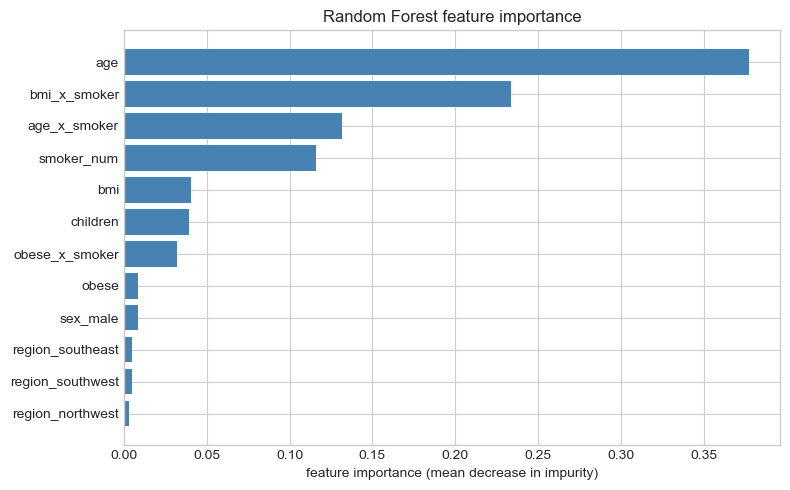

In [27]:
# Step 3 : Feature Importance
rf_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_grid.best_estimator_.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(rf_importance_df['feature'], rf_importance_df['importance'], color='steelblue')
plt.xlabel('feature importance (mean decrease in impurity)')
plt.title('Random Forest feature importance')
plt.tight_layout()
plt.show()

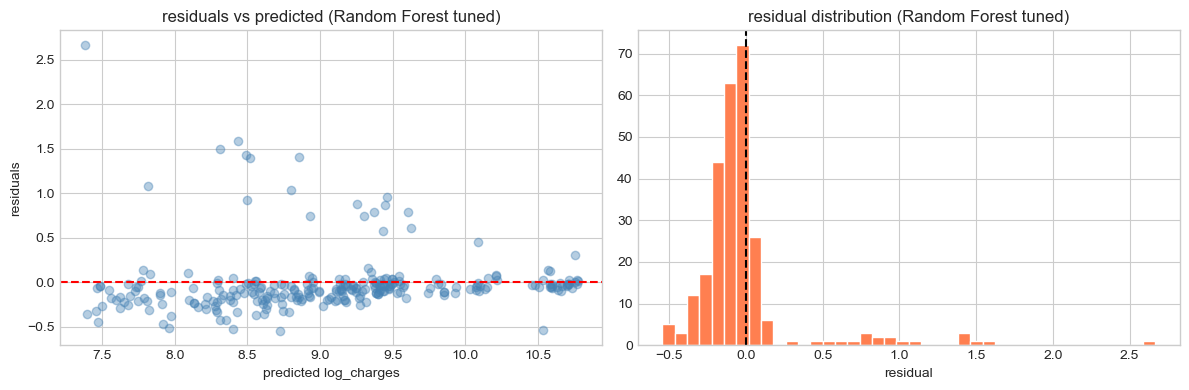

In [28]:
# Step 4 Residual Plot
residuals_rf = y_test - y_pred_rf_tuned

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_rf_tuned, residuals_rf, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('predicted log_charges')
axes[0].set_ylabel('residuals')
axes[0].set_title('residuals vs predicted (Random Forest tuned)')

axes[1].hist(residuals_rf, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('residual')
axes[1].set_title('residual distribution (Random Forest tuned)')

plt.tight_layout()
plt.show()

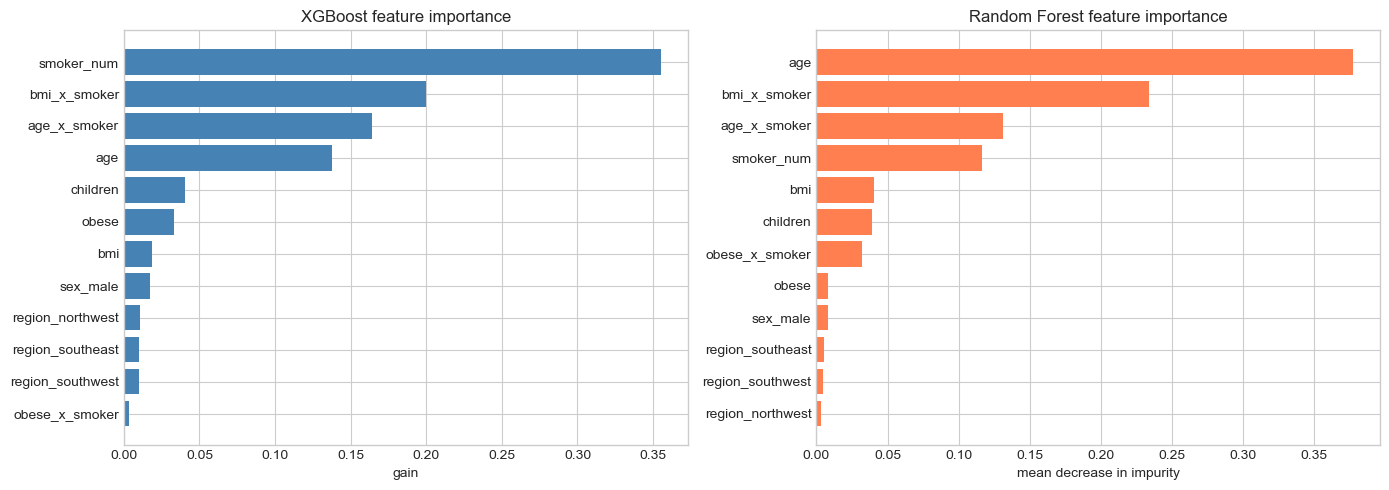

In [29]:
# Step 5 RFM VS XGBOOST comaprison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost
xgb_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': grid_search.best_estimator_.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(xgb_imp['feature'], xgb_imp['importance'], color='steelblue')
axes[0].set_title('XGBoost feature importance')
axes[0].set_xlabel('gain')

# Random Forest
axes[1].barh(rf_importance_df['feature'], rf_importance_df['importance'], color='coral')
axes[1].set_title('Random Forest feature importance')
axes[1].set_xlabel('mean decrease in impurity')

plt.tight_layout()
plt.show()

markdown cell — paste as-is
## Phase 5: Random Forest Results

Random Forest landed exactly where I thought it would — R² 0.8615, RMSE 0.3529,
sitting right between linear regression and XGBoost. At this point the three
models together tell a pretty satisfying story:

| Model | R² | RMSE |
|---|---|---|
| Linear Regression | 0.857 | 0.358 |
| Random Forest (tuned) | 0.862 | 0.353 |
| XGBoost (baseline) | 0.867 | 0.346 |

The gaps are modest, which to me is a good sign — it means the feature engineering
actually worked. The models aren't making up ground for bad inputs, they're just
squeezing out slightly different amounts of signal from the same well-prepared data.

The feature importance comparison was the most interesting part of this phase.
XGBoost puts smoker_num at the top by a wide margin, which makes sense given
everything EDA showed. Random Forest disagrees — it ranks age first and drops
smoker_num to fourth. I initially thought something was off, but it's actually
just how the two algorithms measure importance differently. Random Forest scores
features by how much they reduce impurity across deep trees on the full dataset.
Age has tons of possible split points spread across all 1,338 rows, so it racks
up a high impurity score naturally. XGBoost uses shallow trees focused on fixing
errors, and since the biggest errors cluster around smoker cases, it goes straight
to smoker_num. Neither answer is wrong — they're just asking different questions
about the data.

One thing Random Forest caught that XGBoost mostly ignored was obese_x_smoker.
XGBoost ranked it dead last, but Random Forest gave it real weight. Deep
independent trees apparently picked up on that combined risk profile in a way
the shallow boosted trees didn't need to.

The residuals look almost identical to XGBoost — tight around zero, no obvious
curve, same stubborn right tail of high-cost cases neither model fully nails.
At this point I'm convinced those are just genuinely hard edge cases with too
few similar rows in the training data to learn from cleanly.

**Heading into the final comparison: XGBoost still leads at RMSE 0.3460, R² 0.8669**


## Phase 6 Model Comparsion

In [30]:
#Step1 Summary results table 
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

                   model  RMSE  MAE   R2
      XGBoost (baseline)  0.35 0.18 0.87
         XGBoost (tuned)  0.35 0.19 0.86
   Random Forest (tuned)  0.35 0.19 0.86
   OLS Linear Regression  0.36 0.19 0.86
        Ridge Regression  0.36 0.19 0.86
        Lasso Regression  0.36 0.19 0.86
Random Forest (baseline)  0.37 0.19 0.85


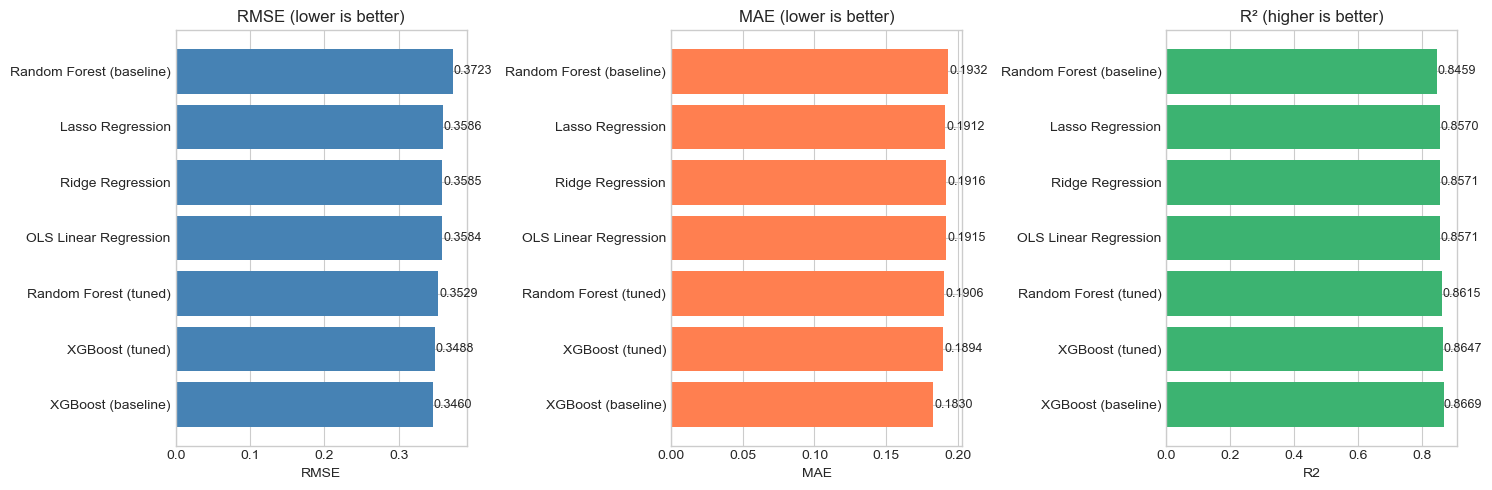

In [31]:
# Step 2 Bar Chart Comparsion RMSE R^2 MAE
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['RMSE', 'MAE', 'R2']
colors = ['steelblue', 'coral', 'mediumseagreen']
titles = ['RMSE (lower is better)', 'MAE (lower is better)', 'R² (higher is better)']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    ax.barh(results_df['model'], results_df[metric], color=color)
    ax.set_title(title)
    ax.set_xlabel(metric)
    # Add value labels on bars
    for i, v in enumerate(results_df[metric]):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

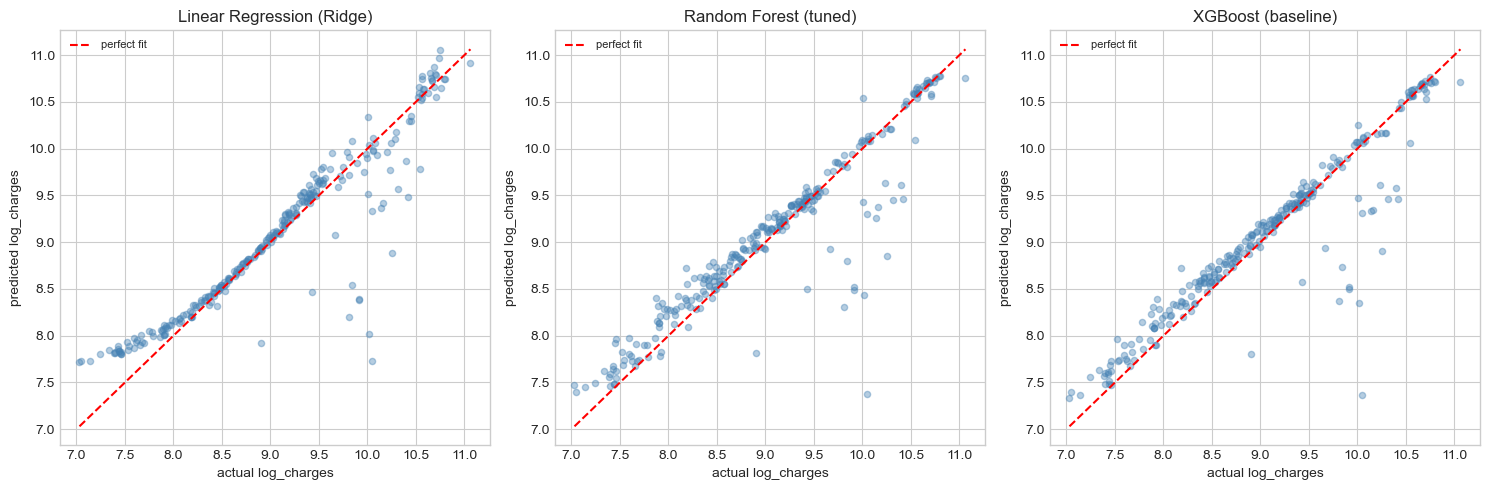

In [32]:
# Step 3 Actual vs Predicted 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_preds = [
    ('Linear Regression (Ridge)', y_pred_ridge),
    ('Random Forest (tuned)', y_pred_rf_tuned),
    ('XGBoost (baseline)', y_pred_xgb)
]

for ax, (name, preds) in zip(axes, model_preds):
    ax.scatter(y_test, preds, alpha=0.4, color='steelblue', s=20)
    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linestyle='--', linewidth=1.5, label='perfect fit')
    ax.set_xlabel('actual log_charges')
    ax.set_ylabel('predicted log_charges')
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

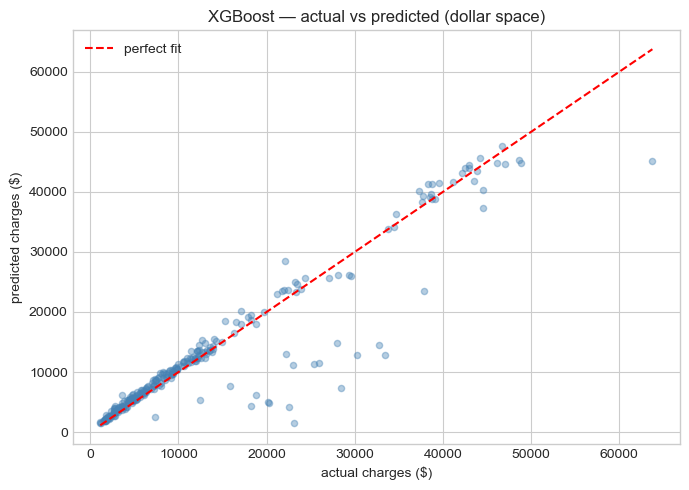

Dollar RMSE: $4,335.82
Dollar MAE:  $1,941.04


In [33]:
# Step 4 Convert best model predictions back to dollars
# Exponentiate back to raw dollar values
y_test_dollars = np.exp(y_test)
y_pred_dollars = np.exp(y_pred_xgb)

# Scatter in dollar space
plt.figure(figsize=(7, 5))
plt.scatter(y_test_dollars, y_pred_dollars, alpha=0.4, color='steelblue', s=20)
plt.plot([y_test_dollars.min(), y_test_dollars.max()],
         [y_test_dollars.min(), y_test_dollars.max()],
         color='red', linestyle='--', linewidth=1.5, label='perfect fit')
plt.xlabel('actual charges ($)')
plt.ylabel('predicted charges ($)')
plt.title('XGBoost — actual vs predicted (dollar space)')
plt.legend()
plt.tight_layout()
plt.show()

# Dollar-space error metrics
dollar_rmse = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
dollar_mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
print(f"Dollar RMSE: ${dollar_rmse:,.2f}")
print(f"Dollar MAE:  ${dollar_mae:,.2f}")

## Phase 6: Model Comparison & Conclusions

| Model | RMSE | MAE | R² |
|---|---|---|---|
| XGBoost (baseline) | 0.346 | 0.183 | 0.867 |
| XGBoost (tuned) | 0.349 | 0.189 | 0.865 |
| Random Forest (tuned) | 0.353 | 0.191 | 0.862 |
| OLS / Ridge / Lasso | 0.358 | 0.191 | 0.857 |
| Random Forest (baseline) | 0.372 | 0.193 | 0.846 |

XGBoost wins across every metric, but the margins are smaller than I expected
going in. The gap between XGBoost and linear regression is only about 0.012
RMSE and 0.01 R²  which tells me the feature engineering in Phase 2 was
doing most of the work all along. By the time any of these models saw the data,
the log transform, interaction terms, and obese flag had already captured the
main structure. The models were competing over the scraps.

### What the actual vs predicted plots showed

Looking at all three side by side made the differences concrete. Linear regression
holds up well in the low to mid range but starts drifting from the diagonal around
actual log_charges of 9.5+. Random Forest is tighter but has a visible cluster of
points hanging off the line in the mid range. XGBoost hugs the diagonal most
consistently across the full range  not perfect, but the spread is more even and
there are fewer cases badly off the line.

### Dollar space — the number that actually matters

Converting back to raw dollars: RMSE of $4,336 and MAE of $1,941. The gap between
those two numbers is the real story. RMSE looks bad because a handful of extreme
high-cost cases get heavily penalized by the squared error — one patient with
actual charges of $63k predicted at $45k blows the RMSE up on its own. MAE is
the honest metric here. Being off by an average of ~$1,941 per patient on a
dataset where charges range from $1,122 to $63,770 is reasonable, especially
with only 7 input features and no medical history, claims data, or pre existing
condition information.

The dollar space scatter plot made this obvious  the model is essentially
perfect on low cost patients under $15k, which is most of the dataset. The
spread opens up as charges increase, and the worst predictions are concentrated
in the $20k–$35k range where smokers and non-smokers start to overlap in ways
the model can't always untangle cleanly.

### What would actually improve this

More data and richer features would close that gap  specifically claims history,
pre-existing conditions, and medication usage. Those are the variables that
explain why two 45-year-old smokers with similar BMI can have wildly different
costs. Without them, any model is going to struggle on the high-cost tail
regardless of how well it's tuned.

### Final take

XGBoost is the right model for this dataset. It's the best performer, it handles
the non linearity the linear model couldn't capture, and it's interpretable enough
through feature importance to explain which variables are driving predictions. The
interaction terms I built in Phase 2 showed up as top features in both tree models,
which validated that the EDA-driven feature engineering decisions were correct.
If I were deploying this, I'd use XGBoost with SHAP values for individual
prediction explanations  which is exactly what Phase 7 (Ollama LLM explanations)
is designed to build on.


## Phase 7 : LLM Explanation with Ollama

In [ ]:
# LLM assisted explanation — show everything the model sees then get the analysis
import ollama
import textwrap

sample_idx    = np.random.randint(0, len(X_test))
sample_raw    = X_test.iloc[sample_idx]
sample_actual = np.exp(y_test.iloc[sample_idx])  # convert back to dollars

sample_preds = {
    'Linear Regression': np.exp(y_pred_ols[sample_idx]),
    'Ridge':             np.exp(y_pred_ridge[sample_idx]),
    'Lasso':             np.exp(y_pred_lasso[sample_idx]),
    'Random Forest':     np.exp(y_pred_rf_tuned[sample_idx]),
    'XGBoost':           np.exp(y_pred_xgb[sample_idx])
}

# Dollar metrics for the print block
dollar_metrics = {
    'Linear Regression': (
        np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_ols))),
        r2_score(y_test, y_pred_ols)
    ),
    'Ridge': (
        np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_ridge))),
        r2_score(y_test, y_pred_ridge)
    ),
    'Lasso': (
        np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_lasso))),
        r2_score(y_test, y_pred_lasso)
    ),
    'Random Forest': (
        np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_rf_tuned))),
        r2_score(y_test, y_pred_rf_tuned)
    ),
    'XGBoost': (
        np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_xgb))),
        r2_score(y_test, y_pred_xgb)
    )
}

print("=" * 60)
print("OVERALL MODEL PERFORMANCE ON TEST SET")
print("=" * 60)
for name, (rmse, r2) in dollar_metrics.items():
    print(f"{name:<20} RMSE: ${rmse:,.2f}    R²: {r2:.4f}")

print("\n" + "=" * 60)
print("SAMPLE PATIENT PROFILE")
print("=" * 60)
for col, val in sample_raw.to_dict().items():
    print(f"  {col}: {val}")

print("\n" + "=" * 60)
print("MODEL PREDICTIONS FOR THIS PATIENT")
print("=" * 60)
print(f"  Actual charges:              ${sample_actual:,.2f}")
for name, pred in sample_preds.items():
    print(f"  {name:<20} predicted: ${pred:,.2f}")
print("=" * 60)

prompt = f"""
You are a health insurance cost analyst reviewing the results of a machine 
learning project. Five models were trained to predict medical insurance charges.
Here are the overall model performance results on the test set:

{chr(10).join([f"{name:<20} RMSE: ${rmse:,.2f}   R²: {r2:.4f}" 
               for name, (rmse, r2) in dollar_metrics.items()])}

Patient profile:
{chr(10).join([f"  {col}: {val}" for col, val in sample_raw.to_dict().items()])}

Actual charges: ${sample_actual:,.2f}

Model predictions for this patient:
{chr(10).join([f"  {name}: ${pred:,.2f}" for name, pred in sample_preds.items()])}

Do the following in 4-5 sentences:
1. Which model performed best overall and why that makes sense for this type of data
2. How well did each model predict this specific patient and which was closest
3. Based on the patient profile, what factors are likely driving their insurance cost

Be specific, analytical, and write like a data scientist presenting findings 
to a business team.
"""

response = ollama.chat(
    model='llama3.2',
    messages=[{'role': 'user', 'content': prompt}]
)

print("\n" + "=" * 60)
print("LLM ANALYSIS")
print("=" * 60)
# Wrap text at 80 characters with proper indentation
wrapped_text = textwrap.fill(response['message']['content'], 
                              width=80, 
                              initial_indent='', 
                              subsequent_indent='')
print(wrapped_text)
print("=" * 60)

OVERALL MODEL PERFORMANCE ON TEST SET
Linear Regression    RMSE: $4,636.47    R²: 0.8571
Ridge                RMSE: $4,637.17    R²: 0.8571
Lasso                RMSE: $4,601.60    R²: 0.8570
Random Forest        RMSE: $4,390.57    R²: 0.8615
XGBoost              RMSE: $4,335.82    R²: 0.8669

SAMPLE PATIENT PROFILE
  age: 19
  bmi: 17.48
  children: 0
  sex_male: True
  region_northwest: True
  region_southeast: False
  region_southwest: False
  smoker_num: 0
  age_x_smoker: 0
  bmi_x_smoker: 0.0
  obese: 0
  obese_x_smoker: 0

MODEL PREDICTIONS FOR THIS PATIENT
  Actual charges:              $1,621.34
  Linear Regression    predicted: $2,466.92
  Ridge                predicted: $2,475.26
  Lasso                predicted: $2,508.40
  Random Forest        predicted: $1,924.71
  XGBoost              predicted: $1,932.37

LLM ANALYSIS
**Model Performance Analysis**  The XGBoost model performed best overall with an
RMSE of $4,335.82 and R² of 0.8669, indicating its ability to accurately pr